# Quantum Gate Decomposition via Transpilation

**Target Backend:** IQM Spark ODRA 5

**Optimization Level:** 0 (no optimization — raw decomposition)

This notebook demonstrates how individual quantum gates decompose into the native gate set of the IQM Spark ODRA 5 backend. Each gate is placed in a minimal circuit, transpiled at optimization level 0, and the resulting decomposition is visualized.

**Gates investigated:**
- $R_y(\theta)$
- $R_x(\theta)$
- $R_z(\theta)$
- $CR_x(\theta)$ (controlled-$R_x$)
- $CR_y(\theta)$ (controlled-$R_y$)
- $CZ(\theta)$ (controlled-$Z$)
- $CNOT(\theta)$ (CNOT)

## 1. Environment Setup

In [45]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Parameter
from iqm.qiskit_iqm import IQMProvider

## 2. Connect to ODRA 5

In [46]:
provider = IQMProvider("https://odra5.e-science.pl/", token=input("Enter IQM Token: "))
iqm_backend = provider.get_backend()
print(f"Connected to backend: {iqm_backend.name}")

Connected to backend: IQMBackend


## 3. Helper: Transpile & Display

A utility function that takes a circuit, transpiles it for the ODRA backend at `optimization_level=0`, and draws both the original and decomposed circuits side by side.

In [47]:
def show_decomposition(original_qc, gate_name):
    """Transpile a circuit for the IQM backend and display original vs decomposed."""
    transpiled_qc = transpile(original_qc, backend=iqm_backend, optimization_level=0)

    print(f"{'='*60}")
    print(f"  {gate_name} — Decomposition (optimization_level=0)")
    print(f"{'='*60}")

    print(f"\nOriginal circuit ({original_qc.num_qubits} qubit(s), depth {original_qc.depth()}):")
    display(original_qc.draw('mpl', style='iqp'))

    print(f"\nTranspiled circuit ({transpiled_qc.num_qubits} qubit(s), depth {transpiled_qc.depth()}):")
    display(transpiled_qc.draw('mpl', style='iqp'))

    print(f"\nTranspiled gate counts: {dict(transpiled_qc.count_ops())}")
    print()

In [48]:
print(iqm_backend.coupling_map)

[[0, 2], [1, 2], [2, 3], [2, 4]]


## 4. Single-Qubit Gates

### 4.1 $R_y(\theta)$

  Ry(θ) — Decomposition (optimization_level=0)

Original circuit (1 qubit(s), depth 1):


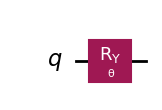


Transpiled circuit (5 qubit(s), depth 1):


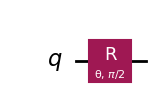


Transpiled gate counts: {'r': 1}



In [49]:
theta = Parameter('θ')

qc_ry = QuantumCircuit(1)
qc_ry.ry(theta, 0)

show_decomposition(qc_ry, 'Ry(θ)')

### 4.2 $R_x(\theta)$

  Rx(θ) — Decomposition (optimization_level=0)

Original circuit (1 qubit(s), depth 1):


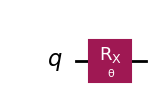


Transpiled circuit (5 qubit(s), depth 1):


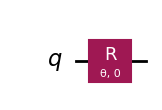


Transpiled gate counts: {'r': 1}



In [50]:
theta = Parameter('θ')

qc_rx = QuantumCircuit(1)
qc_rx.rx(theta, 0)

show_decomposition(qc_rx, 'Rx(θ)')

### 4.3 $R_z(\theta)$

  Rz(θ) — Decomposition (optimization_level=0)

Original circuit (1 qubit(s), depth 1):


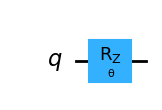


Transpiled circuit (5 qubit(s), depth 3):


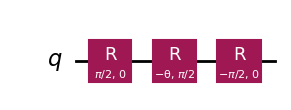


Transpiled gate counts: {'r': 3}



In [51]:
theta = Parameter('θ')

qc_rz = QuantumCircuit(1)
qc_rz.rz(theta, 0)

show_decomposition(qc_rz, 'Rz(θ)')

## 5. Two-Qubit Controlled Gates

### 5.1 $CR_x(\theta)$ (Controlled-$R_x$)

  CRx(θ) — Decomposition (optimization_level=0)

Original circuit (3 qubit(s), depth 1):


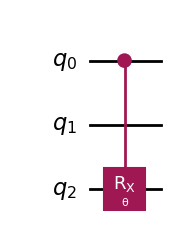


Transpiled circuit (5 qubit(s), depth 18):


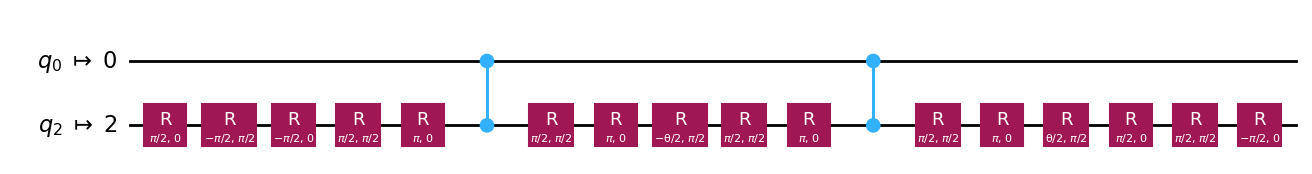


Transpiled gate counts: {'r': 16, 'cz': 2}



In [52]:
theta = Parameter('θ')

qc_crx = QuantumCircuit(3)
qc_crx.crx(theta, 0, 2)

show_decomposition(qc_crx, 'CRx(θ)')

### 5.2 $CR_y(\theta)$ (Controlled-$R_y$)

  CRy(θ) — Decomposition (optimization_level=0)

Original circuit (3 qubit(s), depth 1):


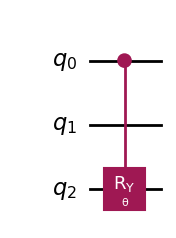


Transpiled circuit (5 qubit(s), depth 12):


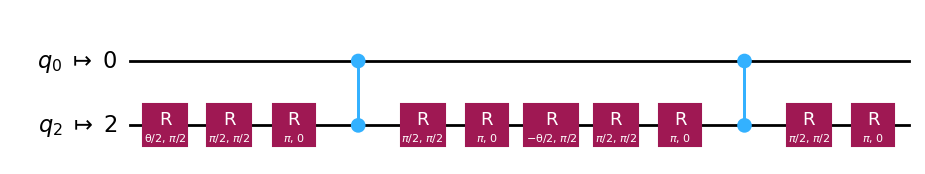


Transpiled gate counts: {'r': 10, 'cz': 2}



In [53]:
theta = Parameter('θ')

qc_cry = QuantumCircuit(3)
qc_cry.cry(theta, 0, 2)

show_decomposition(qc_cry, 'CRy(θ)')

### 5.2 $CZ(\theta)$ (Controlled-$Z$)


  CZ(θ) — Decomposition (optimization_level=0)

Original circuit (3 qubit(s), depth 1):


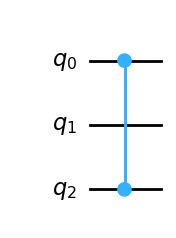


Transpiled circuit (5 qubit(s), depth 1):


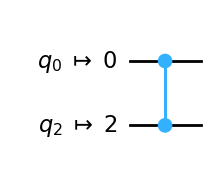


Transpiled gate counts: {'cz': 1}



In [54]:
theta = Parameter('θ')

qc_cz = QuantumCircuit(3)
qc_cz.cz(0, 2)

show_decomposition(qc_cz, 'CZ(θ)')

  CNOT(θ) — Decomposition (optimization_level=0)

Original circuit (3 qubit(s), depth 1):


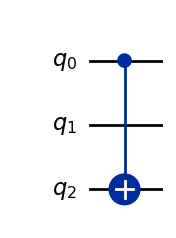


Transpiled circuit (5 qubit(s), depth 5):


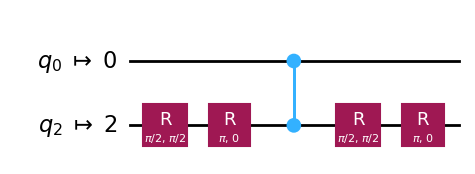


Transpiled gate counts: {'r': 4, 'cz': 1}



In [55]:
theta = Parameter('θ')

qc_cnot = QuantumCircuit(3)
qc_cnot.cx(0, 2)

show_decomposition(qc_cnot, 'CNOT(θ)')

## 6. Summary Comparison

Collect all decomposition metrics into a single table for easy comparison.

In [56]:
import pandas as pd

gates = {
    'Ry(θ)': qc_ry,
    'Rx(θ)': qc_rx,
    'Rz(θ)': qc_rz,
    'CRx(θ)': qc_crx,
    'CRy(θ)': qc_cry,
    'CNOT(θ)': qc_cnot,
    'CZ(θ)': qc_cz
}

rows = []
for name, qc in gates.items():
    t_qc = transpile(qc, backend=iqm_backend, optimization_level=0)
    ops = dict(t_qc.count_ops())
    rows.append({
        'Gate': name,
        'Original Depth': qc.depth(),
        'Transpiled Depth': t_qc.depth(),
        'Transpiled Gate Count': sum(ops.values()),
        'Native Gates Used': ', '.join(sorted(ops.keys())),
    })

df = pd.DataFrame(rows)
df.style.set_caption('Gate Decomposition Summary — ODRA 5 (opt_level=0)')

,Gate,Original Depth,Transpiled Depth,Transpiled Gate Count,Native Gates Used
0,Ry(θ),1,1,1,r
1,Rx(θ),1,1,1,r
2,Rz(θ),1,3,3,r
3,CRx(θ),1,18,18,"cz, r"
4,CRy(θ),1,12,12,"cz, r"
5,CNOT(θ),1,5,5,"cz, r"
6,CZ(θ),1,1,1,cz
